In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, r2_score,
    classification_report,
)

sns.set_theme(style="whitegrid")
SEED = 42

In [2]:
# Load
df = pd.read_csv("../data/online_shoppers_intention.csv")
print(f"Raw shape: {df.shape}")

# Drop features with severe pairwise collinearity — see ML_experiments_decisions.md
# BounceRates:             r = 0.913 with ExitRates (ExitRates kept — stronger Revenue signal)
# ProductRelated_Duration: r = 0.861 with ProductRelated (count kept — marginally stronger
#                          signal and more interpretable)
cols_to_drop = [
    "BounceRates",
    "ProductRelated_Duration",
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print(f"Shape after drops: {df.shape}")
display(df.head())

Raw shape: (12330, 18)
Shape after drops: (12330, 16)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
# One-hot encode categorical columns
# OperatingSystems / Browser / Region / TrafficType are integer-coded *nominal* IDs —
# treating them as continuous would impose a fake ordering (see ML_experiments_decisions.md)
cat_cols = [
    "Month", "OperatingSystems", "Browser", "Region",
    "TrafficType", "VisitorType", "Weekend",
]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Features / target split — SpecialDay stays numeric (ordinal proximity measure, 0 → 1)
X = df.drop(columns=["Revenue"]).astype(float)
y = df["Revenue"].astype(int)

# 80 / 20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Train shape : {X_train.shape}")
print(f"Test  shape : {X_test.shape}")
# y.mean() on a 0/1 column = proportion of sessions that ended in a purchase
print(f"Train purchase rate : {y_train.mean():.2%}")
print(f"Test  purchase rate : {y_test.mean():.2%}")

# Standardize — fit only on train to avoid data leakage into test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("\nStandardization done — mean≈0, std≈1 on training set")

Train shape : (9864, 66)
Test  shape : (2466, 66)
Train purchase rate : 15.47%
Test  purchase rate : 15.49%

Standardization done — mean≈0, std≈1 on training set


In [4]:
def compute_metrics(y_true, y_pred, y_prob=None, model_name="Model"):
    """Return a labelled Series of classification + regression-style metrics."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # MAPE and MRE are undefined when y_true == 0; restrict to positive class rows
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
        mre  = np.mean((y_pred[mask] - y_true[mask]) / y_true[mask]) * 100
    else:
        mape = mre = float("nan")

    metrics = {
        "Accuracy"   : accuracy_score(y_true, y_pred),
        "Precision"  : precision_score(y_true, y_pred, zero_division=0),
        "Recall"     : recall_score(y_true, y_pred, zero_division=0),
        "F1"         : f1_score(y_true, y_pred, zero_division=0),
        "R²"         : r2_score(y_true, y_pred),
        "MAPE (%)"   : round(mape, 4),
        "MRE (%)"    : round(mre, 4),
    }
    if y_prob is not None:
        metrics["AUC-ROC"] = roc_auc_score(y_true, y_prob)
        metrics["PR-AUC"]  = average_precision_score(y_true, y_prob)

    return pd.Series(metrics, name=model_name)

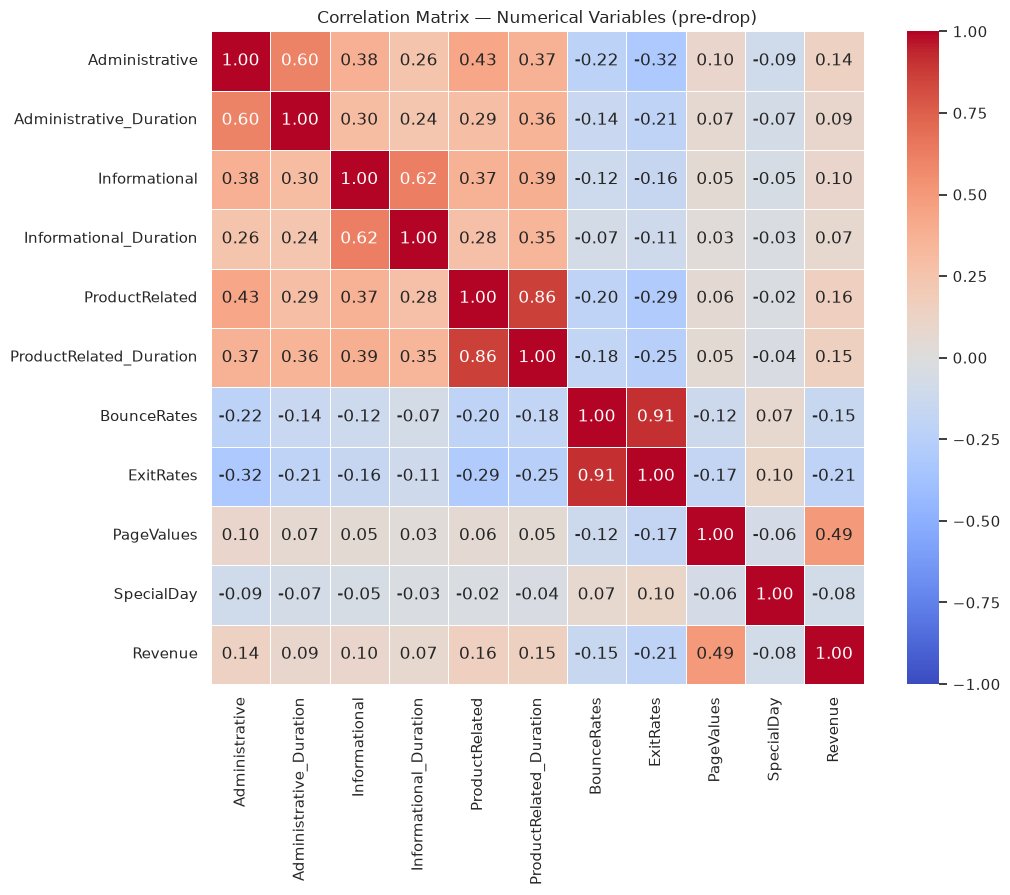


Variance Inflation Factor (VIF)  —  threshold: VIF > 10 indicates problematic multicollinearity
Here no feature crosses 10 — the drops are driven by the pairwise correlations
(BounceRates ↔ ExitRates r=0.91, ProductRelated ↔ ProductRelated_Duration r=0.86)


,Feature,VIF
0,ProductRelated,6.339345
1,ProductRelated_Duration,6.012012
2,ExitRates,5.978858
3,BounceRates,5.557495
4,Administrative,2.651491
5,Informational,2.113723
6,Administrative_Duration,2.041915
7,Informational_Duration,1.777154
8,SpecialDay,1.105706
9,PageValues,1.077806


In [5]:
# Correlation + VIF — numerical variables (including target)
# Uses a temporary raw load so the dropped columns can be shown pre-drop
from statsmodels.stats.outliers_influence import variance_inflation_factor

_df_raw = pd.read_csv("../data/online_shoppers_intention.csv")
_df_raw["Revenue"] = _df_raw["Revenue"].astype(float)

num_cols_corr = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay",
    "Revenue",
]

# Correlation heatmap
corr = _df_raw[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Correlation Matrix — Numerical Variables (pre-drop)")
plt.tight_layout()
plt.show()

# VIF — computed on numerical feature columns before any drops
vif_cols = num_cols_corr[:-1]
vif_data = _df_raw[vif_cols].dropna().astype(float)

vif_df = pd.DataFrame({
    "Feature": vif_cols,
    "VIF": [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_cols))],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

print("\nVariance Inflation Factor (VIF)  —  threshold: VIF > 10 indicates problematic multicollinearity")
print("Here no feature crosses 10 — the drops are driven by the pairwise correlations")
print("(BounceRates ↔ ExitRates r=0.91, ProductRelated ↔ ProductRelated_Duration r=0.86)")
display(vif_df)

del _df_raw

In [6]:
# Dummy Classifier
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train_scaled, y_train)

y_pred_dummy = dummy.predict(X_test_scaled)
y_prob_dummy = dummy.predict_proba(X_test_scaled)[:, 1]

print("=== Dummy Classifier ===")
print(classification_report(y_test, y_pred_dummy, target_names=["No Purchase", "Purchase"]))
display(compute_metrics(y_test, y_pred_dummy, y_prob_dummy, "Dummy Classifier").to_frame())

=== Dummy Classifier ===
              precision    recall  f1-score   support

 No Purchase       0.85      1.00      0.92      2084
    Purchase       0.00      0.00      0.00       382

    accuracy                           0.85      2466
   macro avg       0.42      0.50      0.46      2466
weighted avg       0.71      0.85      0.77      2466



/home/gabe/workspace/Tech-Challenge-02/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabe/workspace/Tech-Challenge-02/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/gabe/workspace/Tech-Challenge-02/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

,Dummy Classifier
Accuracy,0.845093
Precision,0.000000
Recall,0.000000
F1,0.000000
R²,-0.183301
MAPE (%),100.000000
MRE (%),-100.000000
AUC-ROC,0.500000
PR-AUC,0.154907


In [7]:
# Logistic Regression — classification threshold lowered to 0.3
# Justification: see ML_experiments_decisions.md
THRESHOLD = 0.3

lr = LogisticRegression(random_state=SEED, max_iter=10000)
lr.fit(X_train_scaled, y_train)

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob_lr >= THRESHOLD).astype(int)

print(f"=== Logistic Regression (threshold={THRESHOLD}) ===")
print(classification_report(y_test, y_pred_lr, target_names=["No Purchase", "Purchase"]))
display(compute_metrics(y_test, y_pred_lr, y_prob_lr, "Logistic Regression").to_frame())

=== Logistic Regression (threshold=0.3) ===
              precision    recall  f1-score   support

 No Purchase       0.92      0.95      0.93      2084
    Purchase       0.67      0.54      0.60       382

    accuracy                           0.89      2466
   macro avg       0.79      0.75      0.77      2466
weighted avg       0.88      0.89      0.88      2466



,Logistic Regression
Accuracy,0.886861
Precision,0.665595
Recall,0.541885
F1,0.597403
R²,0.135756
MAPE (%),45.811500
MRE (%),-45.811500
AUC-ROC,0.880079
PR-AUC,0.613990


In [8]:
# Random Forest — same hyperparameters as the production model (src/modelo.py)
# At the default threshold 0.5 this shallow forest almost never fires (recall ≈ 0.03):
# with max_depth=5 the predicted probabilities rarely exceed 0.5 — see decisions log
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=SEED)
rf.fit(X_train_scaled, y_train)

y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = (y_prob_rf >= THRESHOLD).astype(int)

print(f"=== Random Forest (threshold={THRESHOLD}) ===")
print(classification_report(y_test, y_pred_rf, target_names=["No Purchase", "Purchase"]))
display(compute_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest").to_frame())

=== Random Forest (threshold=0.3) ===
              precision    recall  f1-score   support

 No Purchase       0.95      0.92      0.93      2084
    Purchase       0.61      0.71      0.66       382

    accuracy                           0.89      2466
   macro avg       0.78      0.82      0.79      2466
weighted avg       0.89      0.89      0.89      2466



,Random Forest
Accuracy,0.885239
Precision,0.610738
Recall,0.714660
F1,0.658625
R²,0.123366
MAPE (%),28.534000
MRE (%),-28.534000
AUC-ROC,0.903172
PR-AUC,0.705127


=== All-model metrics comparison ===


,Dummy Classifier,Logistic Regression,Random Forest
Accuracy,0.845093,0.886861,0.885239
Precision,0.000000,0.665595,0.610738
Recall,0.000000,0.541885,0.714660
F1,0.000000,0.597403,0.658625
R²,-0.183301,0.135756,0.123366
MAPE (%),100.000000,45.811500,28.534000
MRE (%),-100.000000,-45.811500,-28.534000
AUC-ROC,0.500000,0.880079,0.903172
PR-AUC,0.154907,0.613990,0.705127



Best model per metric (LR vs RF):


,Best
Accuracy,Logistic Regression
Precision,Logistic Regression
Recall,Random Forest
F1,Random Forest
R²,Logistic Regression
MAPE (%),Logistic Regression
MRE (%),Random Forest
AUC-ROC,Random Forest
PR-AUC,Random Forest


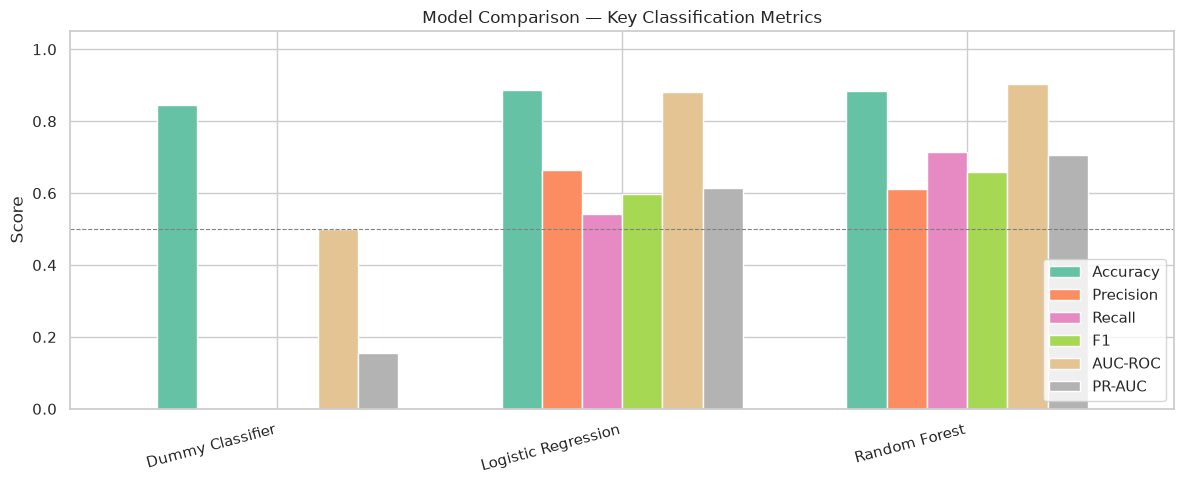

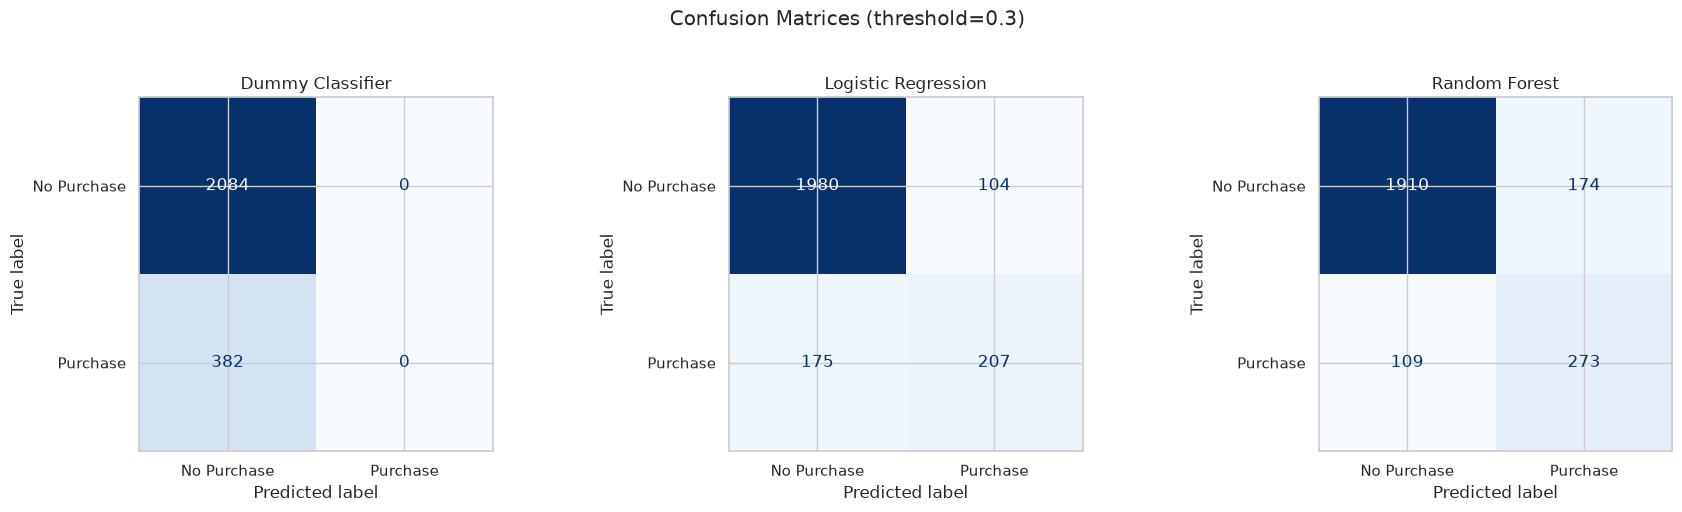

In [9]:
# Full metrics comparison — Dummy vs Logistic Regression vs Random Forest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dummy_metrics = compute_metrics(y_test, y_pred_dummy, y_prob_dummy, "Dummy Classifier")
lr_metrics    = compute_metrics(y_test, y_pred_lr,    y_prob_lr,    "Logistic Regression")
rf_metrics    = compute_metrics(y_test, y_pred_rf,    y_prob_rf,    "Random Forest")

comparison = pd.concat([dummy_metrics, lr_metrics, rf_metrics], axis=1)
print("=== All-model metrics comparison ===")
display(comparison)

# Highlight best value per row (excluding Dummy for context)
best = comparison[["Logistic Regression", "Random Forest"]].idxmax(axis=1)
print("\nBest model per metric (LR vs RF):")
display(best.to_frame("Best"))

# Bar chart for key classification metrics
key_metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC", "PR-AUC"]
comp_plot = comparison.loc[key_metrics].T

fig, ax = plt.subplots(figsize=(12, 5))
comp_plot.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white", width=0.7)
ax.set_title("Model Comparison — Key Classification Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(comp_plot.index, rotation=15, ha="right")
ax.legend(loc="lower right")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, [
    ("Dummy Classifier",    y_pred_dummy),
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)
plt.suptitle("Confusion Matrices (threshold=0.3)", y=1.02)
plt.tight_layout()
plt.show()

/home/gabe/workspace/Tech-Challenge-02/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 9864 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=9864 when initializing the masker.


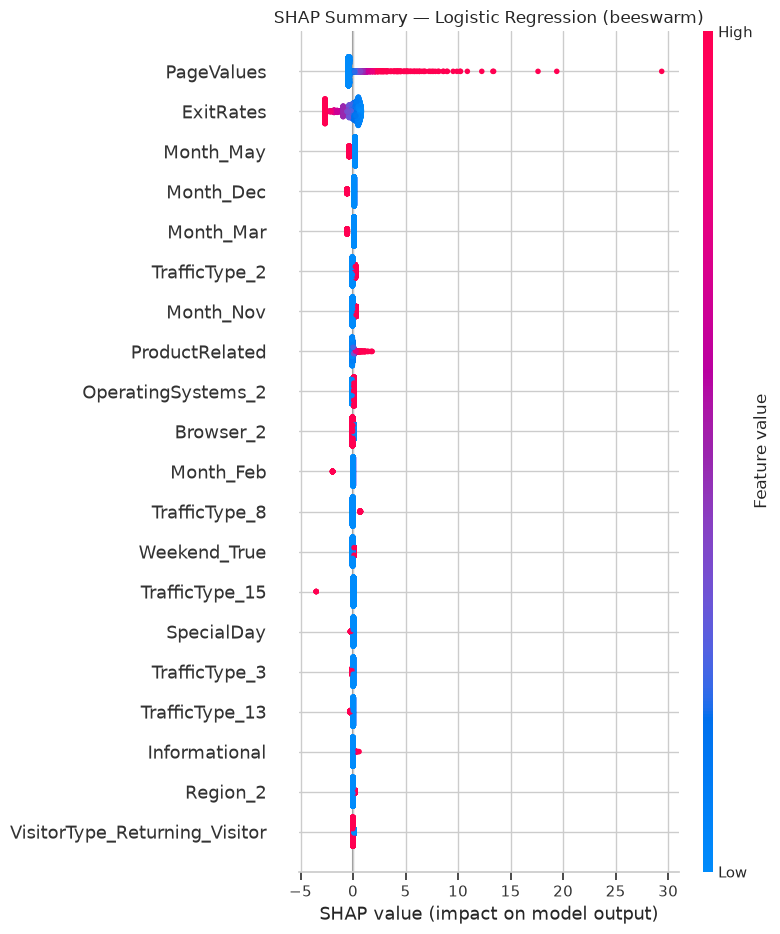

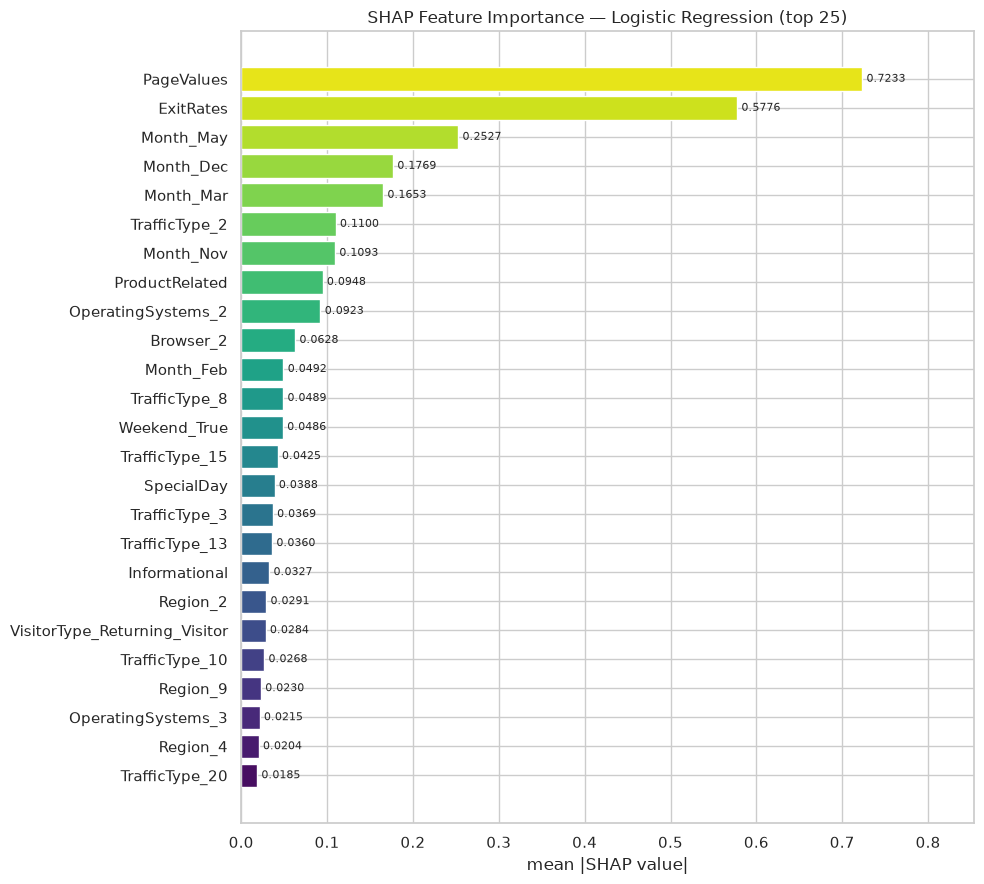

In [10]:
# SHAP values — Logistic Regression feature contributions
import shap

explainer = shap.LinearExplainer(lr, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

feature_names = X.columns.tolist()

# Beeswarm: direction and magnitude per prediction (top 20 features)
plt.figure()
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title("SHAP Summary — Logistic Regression (beeswarm)")
plt.tight_layout()
plt.show()

# Bar: mean absolute SHAP with value labels (top 25 of the 66 features)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = (
    pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .head(25)
    .sort_values("mean_abs_shap", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(
    shap_importance["feature"],
    shap_importance["mean_abs_shap"],
    color=sns.color_palette("viridis", len(shap_importance)),
)
for bar, val in zip(bars, shap_importance["mean_abs_shap"]):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", fontsize=8,
    )
ax.set_xlim(0, shap_importance["mean_abs_shap"].max() * 1.18)
ax.set_xlabel("mean |SHAP value|")
ax.set_title("SHAP Feature Importance — Logistic Regression (top 25)")
plt.tight_layout()
plt.show()

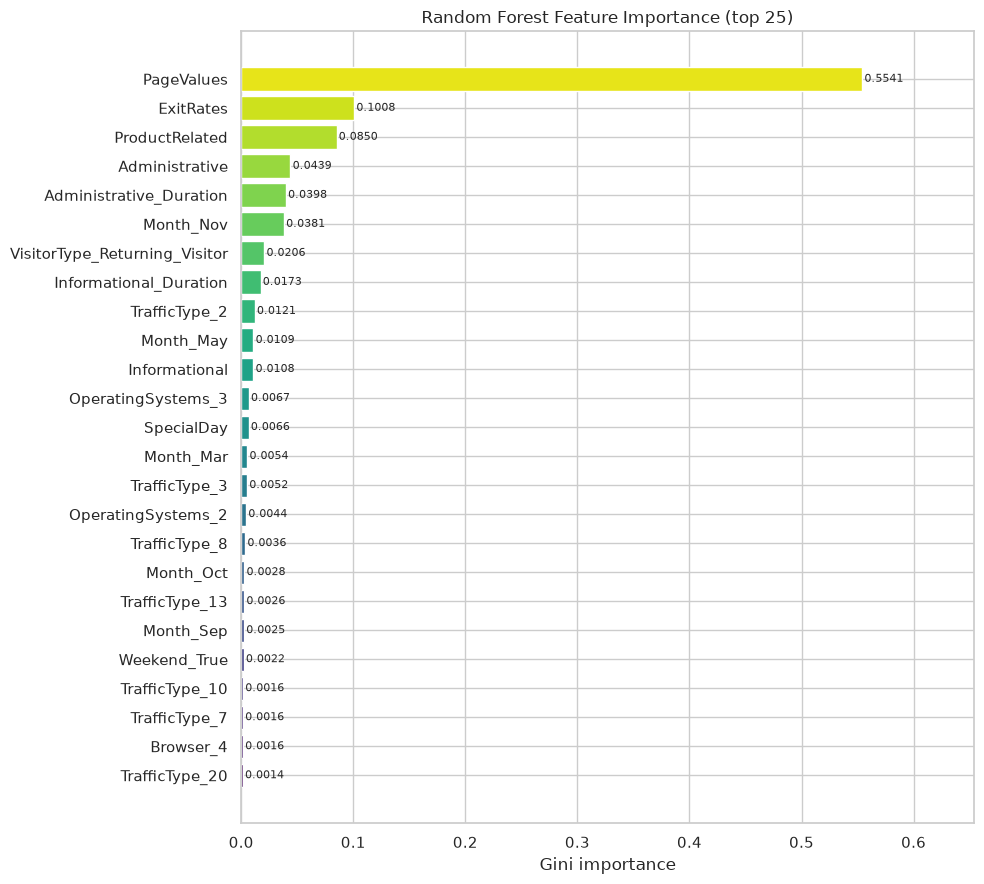

In [11]:
# Random Forest — impurity-based feature importances (top 25)
rf_importance = (
    pd.DataFrame({"feature": X.columns, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(25)
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(
    rf_importance["feature"],
    rf_importance["importance"],
    color=sns.color_palette("viridis", len(rf_importance)),
)
for bar, val in zip(bars, rf_importance["importance"]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center", fontsize=8,
    )
ax.set_xlim(0, rf_importance["importance"].max() * 1.18)
ax.set_xlabel("Gini importance")
ax.set_title("Random Forest Feature Importance (top 25)")
plt.tight_layout()
plt.show()

In [12]:
# MLflow tracking — log this notebook's runs to the shared store
# (same sqlite backend + experiment as src/modelo.py, so all runs land together;
#  runs are tagged source=ML_experiments.ipynb to distinguish them from pipeline runs)
import os
import pathlib

import mlflow

REPO_ROOT = pathlib.Path.cwd().parent
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", f"sqlite:///{REPO_ROOT / 'mlflow.db'}")
EXPERIMENT_NAME = "Propensao_Compra"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

def mlflow_metrics(y_true, y_pred, y_prob):
    """Metric names restricted to MLflow-safe characters."""
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall"   : recall_score(y_true, y_pred, zero_division=0),
        "f1"       : f1_score(y_true, y_pred, zero_division=0),
        "roc_auc"  : roc_auc_score(y_true, y_prob),
        "pr_auc"   : average_precision_score(y_true, y_prob),
    }

notebook_runs = [
    ("dummy_classifier_nb", {"model_type": "DummyClassifier", "strategy": "most_frequent"},
     y_pred_dummy, y_prob_dummy),
    ("logistic_regression_nb", {"model_type": "LogisticRegression", "threshold": THRESHOLD},
     y_pred_lr, y_prob_lr),
    ("random_forest_nb", {"model_type": "RandomForestClassifier", "n_estimators": 100,
                          "max_depth": 5, "threshold": THRESHOLD},
     y_pred_rf, y_prob_rf),
]
for run_name, params, y_pred, y_prob in notebook_runs:
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("source", "ML_experiments.ipynb")
        mlflow.log_params(params)
        metrics = mlflow_metrics(y_test, y_pred, y_prob)
        mlflow.log_metrics(metrics)
        print(f"logged {run_name}: { {k: round(v, 4) for k, v in metrics.items()} }")

logged dummy_classifier_nb: {'accuracy': 0.8451, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.5, 'pr_auc': 0.1549}
logged logistic_regression_nb: {'accuracy': 0.8869, 'precision': 0.6656, 'recall': 0.5419, 'f1': 0.5974, 'roc_auc': 0.8801, 'pr_auc': 0.614}


logged random_forest_nb: {'accuracy': 0.8852, 'precision': 0.6107, 'recall': 0.7147, 'f1': 0.6586, 'roc_auc': 0.9032, 'pr_auc': 0.7051}
